# SC4003 Assignment 1 – Part 1
## Optimal Policy & Utilities using **Policy Iteration**

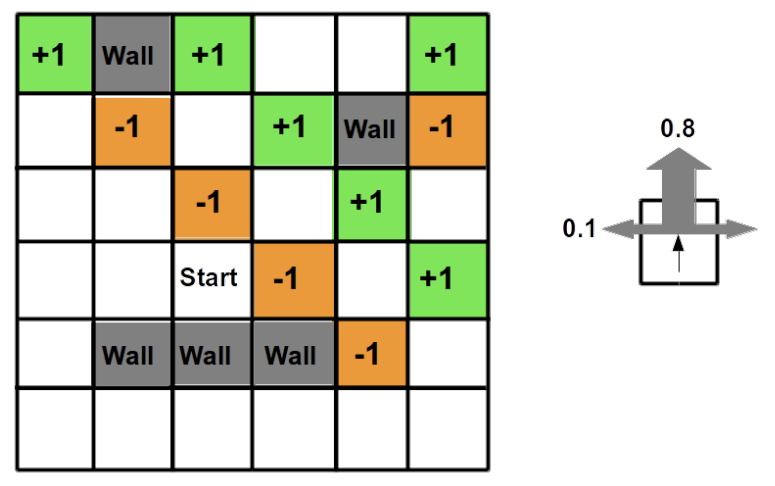

This notebook implements the gridworld:

- **Actions**: Up, Down, Left, Right  
- **Transition model**: 0.8 intended, 0.1 each perpendicular direction  
- **Wall**: Agent stays in place  
- **Rewards**: White = −0.05, Green = +1, Brown = −1  
- **No terminal states** (Infinite state sequence)  
- **Discount factor** = 0.99

---
#### Part 1
Assuming the known transition model and reward function listed above, find the optimal policy and the utilities of all the (non-wall) states using policy iteration. Display the optimal policy and the utilities of all the states, and plot utility estimates as a function of the number of iterations as in Figure 17.5(a) in the above reference book. In this question, use a discount factor of 0.99. 

---
#### Deliverables for Policy Iteration
1. Descriptions of implemented solutions  
2. Plot of optimal policy 
3. Utilities of all states  
4. Plot of utility estimates as a function of the number of iterations

---
#### Coordinate Convention
`(row, col)` with `(0,0)` at **top-left**.   
  
Start cell = `(3, 2)`.

## 1 Imports and Utilities

In [3]:
import os
import sys
from IPython.display import display
from common_utils import *

sys.path.append(os.getcwd())
sys.path.append('/mnt/data')

In [4]:
# Helper Functions for PI outer-iteration plots

def pi_outer_trace(history, outer_endpoints, env=None, state=None, metric='state'):
    """
    Extract one value per outer PI iteration.
    outer_endpoints are direct indices into pi_history.
    metric:
        - 'state': utility of one chosen state
        - 'start': utility of the start state
        - 'mean': mean utility across all non-wall states
    """
    y = []
    for idx in outer_endpoints:
        snapshot = history[idx]

        if metric == 'state':
            if state is None:
                raise ValueError("Provide state when metric='state'.")
            y.append(snapshot[state])

        elif metric == 'start':
            if env is None:
                raise ValueError("Provide env when metric='start'.")
            y.append(snapshot[env.start_state])

        elif metric == 'mean':
            if env is None:
                raise ValueError("Provide env when metric='mean'.")
            y.append(np.mean([snapshot[s] for s in env.states]))

        else:
            raise ValueError("metric must be 'state', 'start', or 'mean'")

    return y


def plot_pi_outer_state_traces(history, outer_endpoints, tracked_states, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(1, len(outer_endpoints) + 1)

    for state in tracked_states:
        y = pi_outer_trace(history, outer_endpoints, state=state, metric='state')
        ax.plot(x, y, marker='o', linewidth=2, label=str(state))

    ax.set_title(title, fontsize=13, weight='bold')
    ax.set_xlabel('Outer Iterations')
    ax.set_ylabel('Utility Estimate')
    ax.grid(alpha=0.3)
    ax.legend(ncol=3, fontsize=9)
    plt.show()


def plot_pi_outer_summary(history, outer_endpoints, env, metric='mean', title=''):
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(1, len(outer_endpoints) + 1)
    y = pi_outer_trace(history, outer_endpoints, env=env, metric=metric)

    ax.plot(x, y, marker='o', linewidth=2)

    ax.set_title(title, fontsize=13, weight='bold')
    ax.set_xlabel('Outer Iterations')
    ax.set_ylabel('Utility Value')
    ax.grid(alpha=0.3)
    plt.show()

## 2 Initialisation
This initialises the Gridworld environment, defines the states that will be tracked in the convergence plots and visualises the given maze.

#### What the maze shows:
- green cells = reward `+1`
- orange/brown cells = reward `-1`
- grey cells = walls
- blue cell = start state
- white cells = normal states with reward `-0.05`

In [6]:
# Gridworld Environment Initialisation
env = Gridworld()

In [7]:
# Define States
TRACKED_STATES = DEFAULT_TRACKED_STATES

print("Start state:", env.start_state)
print("Walls:", sorted(env.walls))
print("Tracked states:", TRACKED_STATES)

Start state: (3, 2)
Walls: [(0, 1), (1, 4), (4, 1), (4, 2), (4, 3)]
Tracked states: [(0, 0), (0, 2), (0, 5), (1, 0), (2, 4), (3, 2), (3, 5), (5, 0), (5, 5)]


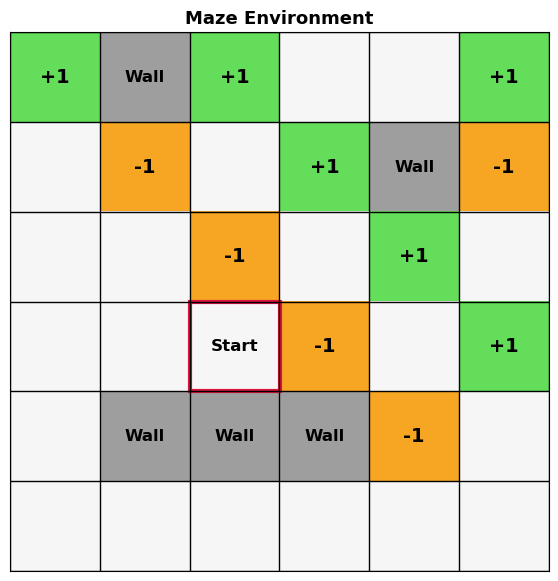

In [8]:
# Visualisation of Given Maze
plot_board(env, title='Maze Environment')

## 3 Run Policy Iteration

This cell runs **Policy Iteration (PI)** on the gridworld to compute the **optimal utility function** and the corresponding **optimal policy**.

---
#### What this step does
Policy Iteration alternates between two phases:

1. **Policy evaluation**: hold the current policy fixed and repeatedly update the utility of each non-wall state until the utility changes become very small.
2. **Policy improvement**: for each non-wall state $s$, compare all four actions and replace the current action with the one that gives the highest expected return under the evaluated utilities.
3. Record how many states changed action after each improvement step.
4. Repeat until the policy no longer changes.

This means PI improves the policy step by step, using the current utility estimates to decide whether a better action exists at each state.

---
#### Implemented policy-evaluation update
In this notebook, rewards are attached to the **next state entered**, so during policy evaluation, the utility update used in code is:

$$
U_{k+1}^{\pi}(s)
=
\sum_{s'} P(s' \mid s,\pi(s))
\left[ R(s') + \gamma U_k^{\pi}(s') \right]
$$

Here, the policy $\pi$ is fixed, so each state is updated using only the action currently assigned by that policy.

---
#### Policy-improvement rule
After the utilities for the current policy have been evaluated, the policy is improved by choosing the action with the highest expected return:

$$
\pi_{\text{new}}(s)
=
\arg\max_a
\sum_{s'} P(s' \mid s,a)
\left[ R(s') + \gamma U^{\pi}(s') \right]
$$

This produces a new greedy policy based on the latest evaluated utilities.

---
#### Stopping rule
The algorithm stops when either:
- the policy improvement step changes **zero** states, meaning the policy is stable
- or the number of outer policy-iteration cycles reaches `MAX_POLICY_ITERATIONS`

During each evaluation phase, the utility sweeps stop when the maximum change falls below the tolerance `THETA_EVAL`, i.e.

$$
\Delta = \max_s \left| U_{k+1}^{\pi}(s) - U_k^{\pi}(s) \right| < \theta_{\text{eval}}
$$

Because $0 < \gamma < 1$, policy evaluation converges for a fixed policy, and Policy Iteration converges to an optimal policy in a finite number of outer iterations.

---
#### Outputs returned by `policy_iteration(...)`
- `U_pi`: final utility values for all non-wall states
- `policy_pi`: final optimal policy
- `pi_history`: utility snapshot after each evaluation sweep
- `pi_deltas`: maximum utility change per evaluation sweep
- `pi_policy_changes`: number of states whose action changed after each policy improvement step
- `pi_outer_endpoints`: sweep indices marking the end of each outer policy-iteration cycle

---
#### How to interpret the results
- **Fewer outer iterations** usually indicate that the policy stabilises quickly
- **More evaluation sweeps** mean a policy took longer to evaluate before improvement
- **Smaller final** $\Delta$ **indicates that the utilities for the current policy have numerically stabilised**
- **A final policy-change count of 0** means the algorithm has converged
- `pi_history` is later used to plot how selected state utilities evolve across evaluation sweeps, giving a more detailed convergence plot than showing only outer iterations

In [10]:
# Run Policy Iteration
THETA_EVAL = 1e-8
MAX_POLICY_ITERATIONS = 10000

U_pi, policy_pi, pi_history, pi_deltas, pi_policy_changes, pi_outer_endpoints = policy_iteration(
    env,
    theta_eval=THETA_EVAL,
    max_policy_iterations=MAX_POLICY_ITERATIONS,
)

print(f"Total policy-evaluation sweeps logged: {len(pi_history) - 1}")
print(f"Number of policy improvement steps: {len(pi_policy_changes)}")
print(f"Final evaluation delta: {pi_deltas[-1]:.3e}")
print("States changed after each improvement step:", pi_policy_changes)
print("Outer-iteration endpoints in evaluation-sweep indexing:", pi_outer_endpoints)

Total policy-evaluation sweeps logged: 3829
Number of policy improvement steps: 5
Final evaluation delta: 9.523e-09
States changed after each improvement step: [19, 8, 3, 3, 0]
Outer-iteration endpoints in evaluation-sweep indexing: [1834, 3543, 3710, 3788, 3829]


## 4 Visualisation of Results

This section shows the **utility snapshots at different sweeps** and the **optimal policy and utilities of all the states**

Because Policy Iteration has only a few outer iterations, but each one contains many evaluation sweeps, so plotting sweeps gives a much more detailed and meaningful view of convergence.

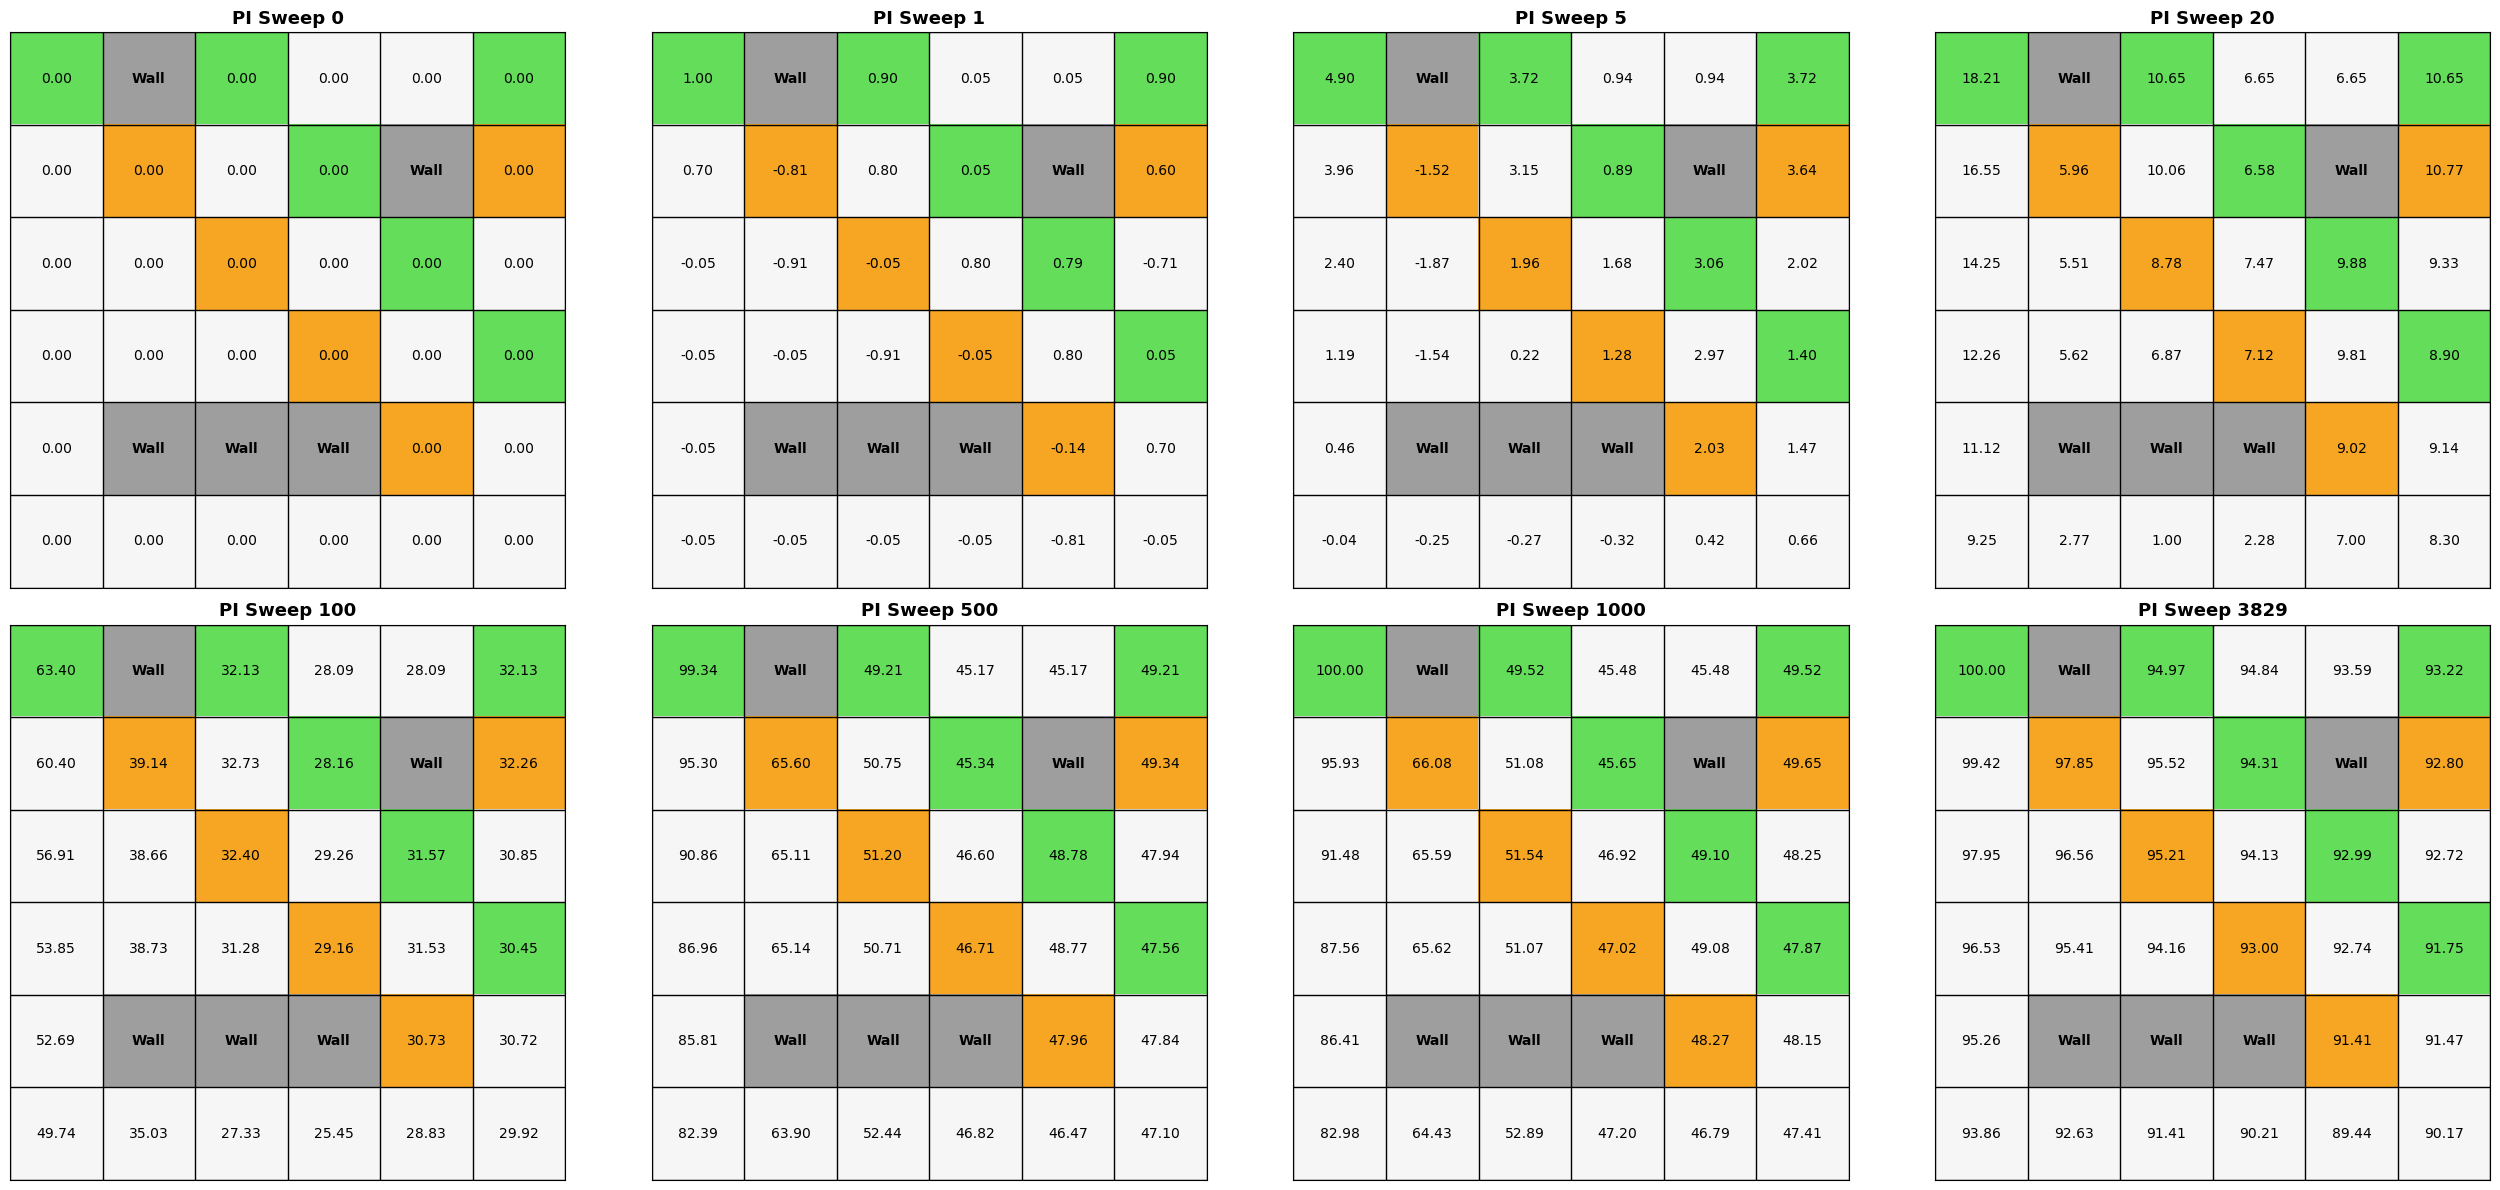

In [12]:
# Utility snapshots at different sweeps
snapshot_sweeps = [0, 1, 5, 20, 100, 500, 1000, len(pi_history) - 1]
plot_snapshot_grid(
    env,
    pi_history,
    snapshot_indices=snapshot_sweeps,
    title_prefix='PI Sweep',
    ncols=4,
)

In [13]:
# Display optimal policy and utilities of all the states
display(utility_table_df(env, U_pi, decimals=3))
display(policy_table_df(env, policy_pi))

,c0,c1,c2,c3,c4,c5
r0,100.000,Wall,94.969,94.836,93.591,93.216
r1,99.425,97.846,95.522,94.310,Wall,92.802
r2,97.952,96.565,95.208,94.125,92.989,92.718
r3,96.529,95.406,94.165,93.001,92.738,91.753
r4,95.263,Wall,Wall,Wall,91.408,91.468
r5,93.861,92.628,91.411,90.209,89.443,90.175


,c0,c1,c2,c3,c4,c5
r0,↑,Wall,←,←,←,↑
r1,↑,←,←,←,Wall,↑
r2,↑,←,←,↑,←,←
r3,↑,←,←,↑,↑,↑
r4,↑,Wall,Wall,Wall,↑,↑
r5,↑,←,←,←,↑,↑


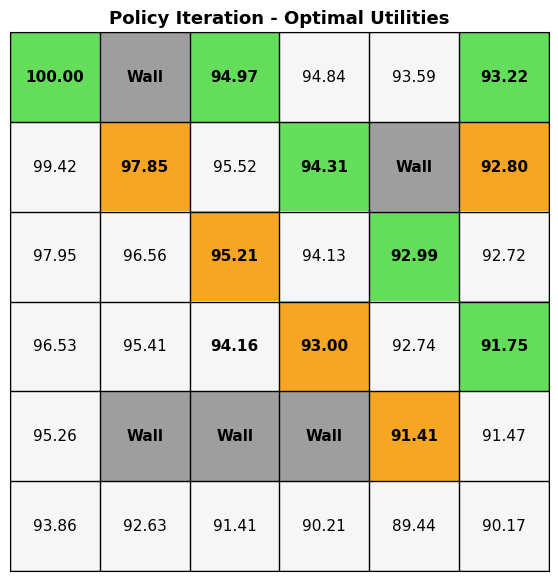

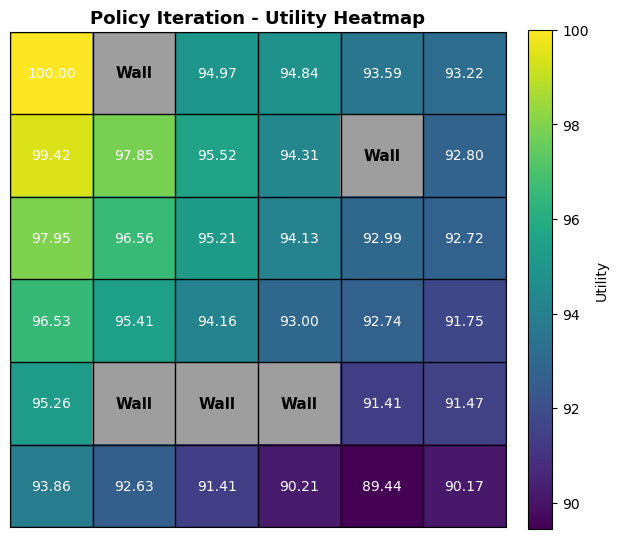

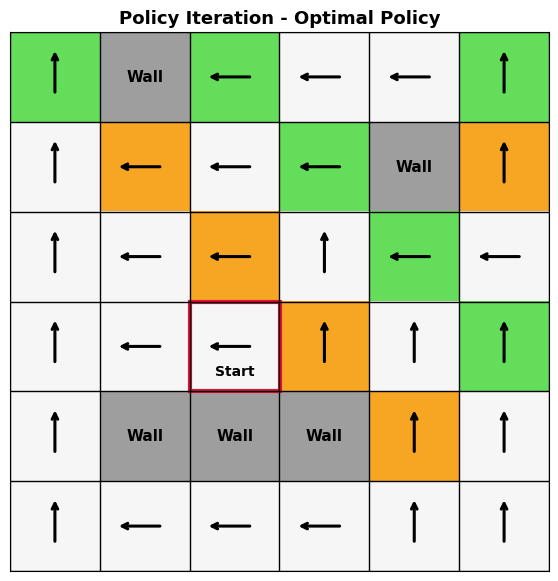

In [14]:
# Visualise optimal policy and utilities of all the states
plot_utilities_on_board(env, U_pi, title='Policy Iteration - Optimal Utilities')
plot_utility_heatmap(env, U_pi, title='Policy Iteration - Utility Heatmap')
plot_policy(env, policy_pi, title='Policy Iteration - Optimal Policy')

## 5 Convergence Plots


The first graph plots utility estimates as a function of the number of **evaluation sweeps** for several states, as in Figure 17.5(a). This gives a more detailed view of Policy Iteration convergence than plotting only the outer policy-improvement steps.

The second graph shows the **evaluation residual** (maximum absolute utility change per sweep) on a log scale. This indicates how quickly the utility estimates stabilise during policy evaluation.

The third graph shows the **number of policy changes per outer iteration**. This tells us how much the policy is still improving after each policy-improvement step.

**How to interpret these plots:**
- Utilities that flatten out are converging
- Smaller residuals indicate numerical stabilization during policy evaluation
- Many policy changes early on suggest the initial policy was far from optimal
- Few or zero policy changes later indicate that the policy is approaching or has reached convergence

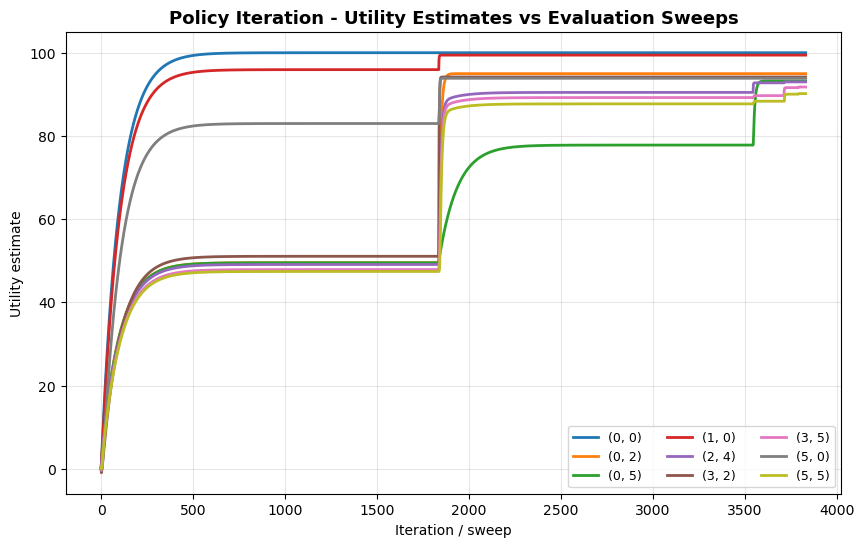

In [16]:
# Plot utility estimates as a function of the number of sweeps
plot_state_traces(
    pi_history,
    TRACKED_STATES,
    title='Policy Iteration - Utility Estimates vs Evaluation Sweeps'
)

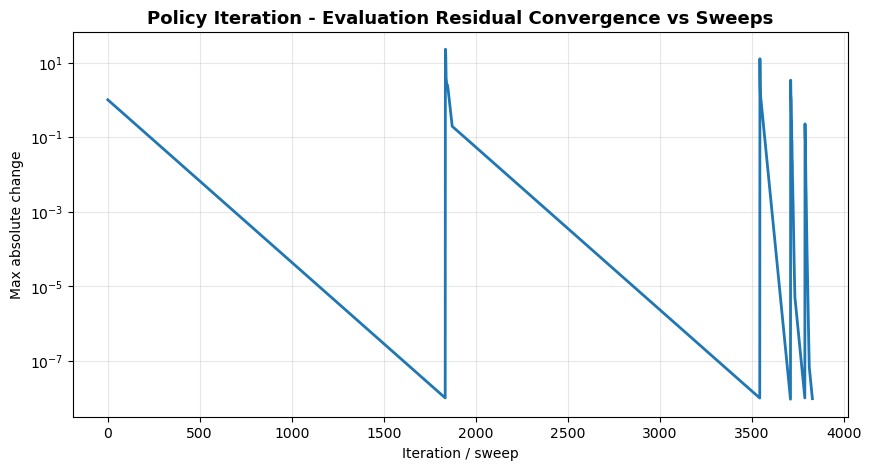

In [17]:
# Plot evaluation residual against sweeps on a log scale
plot_delta_history(
    pi_deltas,
    title='Policy Iteration - Evaluation Residual Convergence vs Sweeps',
    log_scale=True,
)

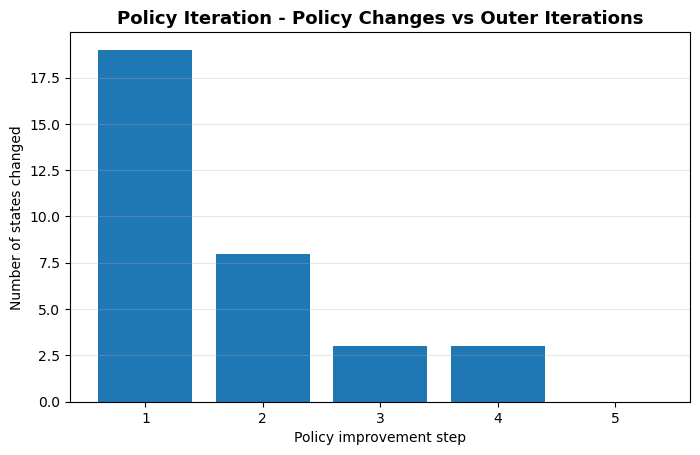

In [18]:
# Plot policy changes against outer iterations
plot_policy_changes(
    pi_policy_changes,
    title='Policy Iteration - Policy Changes vs Outer Iterations'
)

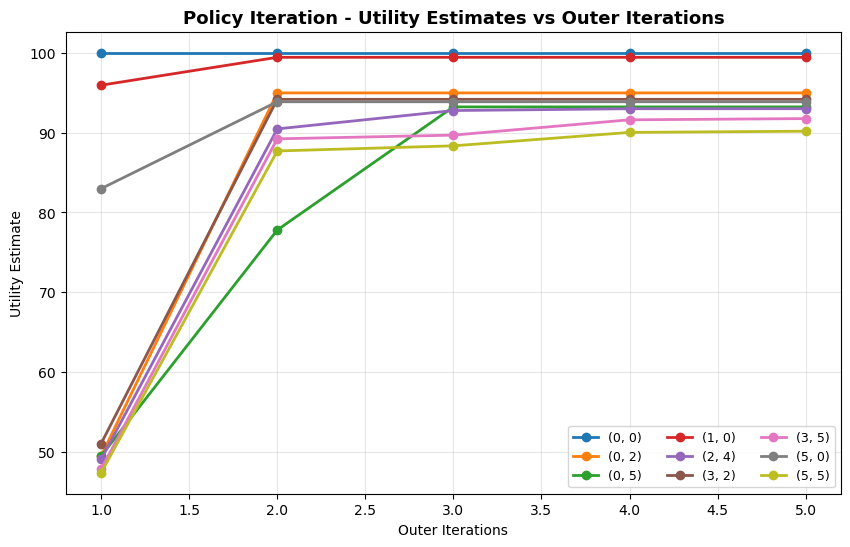

In [19]:
# Plot selected tracked states against PI outer iterations
plot_pi_outer_state_traces(
    pi_history,
    pi_outer_endpoints,
    TRACKED_STATES,
    title='Policy Iteration - Utility Estimates vs Outer Iterations'
)

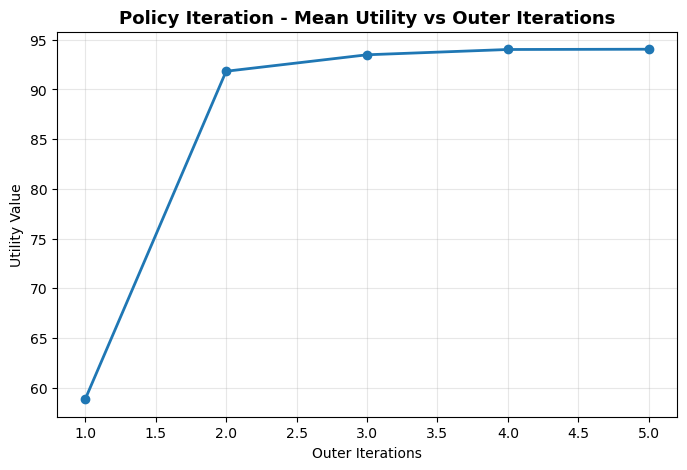

In [20]:
# Plot mean utility against PI outer iterations
plot_pi_outer_summary(
    pi_history,
    pi_outer_endpoints,
    env,
    metric='mean',
    title='Policy Iteration - Mean Utility vs Outer Iterations'
)

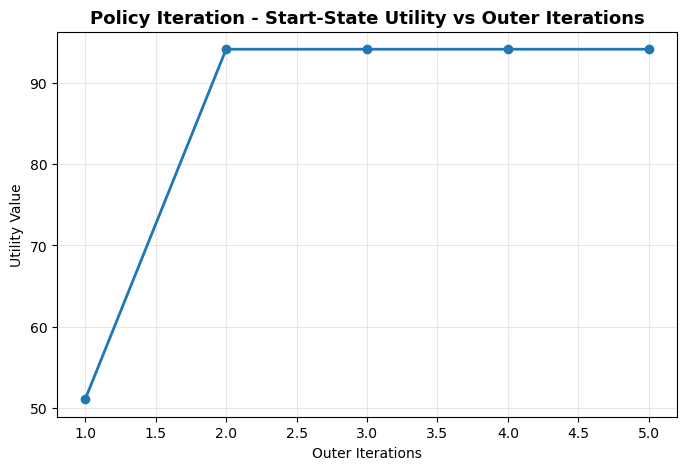

In [21]:
# Plot start-state utility against PI outer iterations
plot_pi_outer_summary(
    pi_history,
    pi_outer_endpoints,
    env,
    metric='start',
    title='Policy Iteration - Start-State Utility vs Outer Iterations'
)

## 6 Correctness Check against Value Iteration

In a known discounted MDP like this, Value Iteration and Policy Iteration should converge to the same optimal solution, up to small tolerance.

#### What this cell checks:
- Maximum absolute difference in final utility values
- Whether the final policies match state by state

In [23]:
# Check Correctness of Result against Value Iteration
U_vi_check, policy_vi_check, _, _ = value_iteration(env, theta=1e-8, max_iterations=10000)

max_abs_diff = max(abs(U_pi[s] - U_vi_check[s]) for s in env.states)
same_policy = all(policy_pi[s] == policy_vi_check[s] for s in env.states)

print(f"Maximum absolute utility difference vs value iteration: {max_abs_diff:.3e}")
print("Policy matches value iteration:", same_policy)

Maximum absolute utility difference vs value iteration: 9.884e-07
Policy matches value iteration: True
